In [9]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import plotly.graph_objects as go
import networkx as nx
from torch_geometric.data import Batch

# 尝试导入 forgi（可选）
try:
    import forgi.visual.mplotlib as fvm
    import forgi
    FORGI_AVAILABLE = True
except ImportError:
    FORGI_AVAILABLE = False
    print("Warning: forgi not available. Install with: pip install forgi")

# 导入项目相关模块
from model.main_model import RNA_ClassQuery_Model
from dataset.human import Mer100Dataset, one_hot_to_sequence

# 设置 Matplotlib 样式
plt.style.use('seaborn-v0_8-whitegrid')

print("所有库导入成功！")

所有库导入成功！


In [10]:
# 1. 加载配置
config_path = 'json/human.json'
with open(config_path, 'r') as f:
    config = json.load(f)

# 2. 实例化数据集并获取单个样本
# 注意：我们这里只用于推理，所以只取训练集的一个样本即可
dataset = Mer100Dataset(mode='train', use_human3=True)
sample = dataset[0]  # 获取第一个样本
seq = one_hot_to_sequence(sample.x.numpy())
label = sample.y_site.numpy()

# 从 edge_index 构建邻接矩阵（GCN使用的图结构）
edge_index = sample.edge_index.numpy()
num_nodes = sample.x.shape[0]
adj_matrix = np.zeros((num_nodes, num_nodes))
adj_matrix[edge_index[0], edge_index[1]] = 1

print(f"成功加载样本，序列长度: {len(seq)}")
print(f"邻接矩阵形状: {adj_matrix.shape}")
print(f"邻接矩阵非零元素数: {np.count_nonzero(adj_matrix)}")
print(f"边数: {edge_index.shape[1]}")

# 3. 实例化模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNA_ClassQuery_Model(**config['model']).to(device)

# 4. 加载模型权重
checkpoint_path = 'logs/rna_classification_20260119_163921/checkpoints/epoch_030.pt'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"模型加载成功并设置为评估模式。")

使用内存映射加载human3数据: /home/dc/vscode/vscode20251230/human_and_plant/human3
数据集初始化完成 (mode=train):
  总样本数: 203993
  序列形状: (203993, 1001), dtype: |S1
  1001loc形状: (203993, 1001), dtype: int8
  12loc形状: (203993, 12), dtype: int8
  4loc形状: (203993, 4), dtype: int8
正在从批量缓存加载边索引: /home/dc/vscode/vscode20260119/rgcnformer_sum/cache/human_train_structures_cache.npz
  已加载 203993 个边索引
  缓存文件大小: 536.66 MB
成功加载样本，序列长度: 1001
邻接矩阵形状: (1001, 1001)
邻接矩阵非零元素数: 2000
边数: 2000
Initializing HierarchicalClassQueryHeadPooling with group_to_class_indices: {'A': [0, 1, 7, 9, 10], 'C': [2, 6, 8], 'G': [3, 11], 'U': [4, 5]}
  Group 0 ('A'): 5 subclasses, indices: [0, 1, 7, 9, 10]
  Group 1 ('C'): 3 subclasses, indices: [2, 6, 8]
  Group 2 ('G'): 2 subclasses, indices: [3, 11]
  Group 3 ('U'): 2 subclasses, indices: [4, 5]
模型加载成功并设置为评估模式。


In [11]:
# 1. 准备模型输入
# 使用 PyG 的 Batch 功能来打包单个样本
batch = Batch.from_data_list([sample])
batch = batch.to(device)

# 2. 执行预测
# 设置每个类别的分类阈值（使用表中提供的最优阈值）
# 12类修饰的最优阈值
thresholds_12class = [0.510, 0.400, 0.690, 0.710, 0.350, 0.150, 0.120, 0.380, 0.350, 0.260, 0.570, 0.130]
# 4类核苷酸分组的最优阈值
thresholds_4class = [0.980, 0.270, 0.050, 0.050]  # A, C, G, U

with torch.no_grad():
    # 由于配置了 use_hierarchical=True，模型返回 (logits_12class, logits_4class)
    logits_12class, logits_4class,atten_weight = model(batch.x, batch.edge_index, batch.batch)
    
    # 使用12类分类的logits计算概率
    # logits_12class: [batch_size, 12] - 12个修饰类别的预测
    prediction_probs = torch.sigmoid(logits_12class)  # 多标签分类使用sigmoid
    
    # 使用4类分类的logits计算概率
    # logits_4class: [batch_size, 4] - 4个核苷酸分组的预测
    prediction_probs_4class = torch.sigmoid(logits_4class)
    
    # 获取第一个样本的所有类别概率
    probs = prediction_probs[0].cpu().numpy()  # [12] -> numpy array
    probs_4class = prediction_probs_4class[0].cpu().numpy()  # [4] -> numpy array
    
    # 应用每个类别的独立阈值确定预测结果（使用numpy向量化操作）
    predictions_12class = (probs >= np.array(thresholds_12class)).astype(int)  # [12]
    predictions_4class = (probs_4class >= np.array(thresholds_4class)).astype(int)  # [4]

# 12类修饰名称映射
MOD_NAMES = {
    0: 'Am',     1: 'Atol',   2: 'Cm',
    3: 'Gm',     4: 'Tm',     5: 'Y',
    6: 'ac4C',   7: 'm1A',    8: 'm5C',
    9: 'm6A',    10: 'm6Am',  11: 'm7G'
}

In [12]:
print(f"模型预测完成。")

print(f"\n{'='*80}")
print(f"12类修饰预测结果 (第一个样本)")
print(f"{'='*80}")
print(f"{'类别':<6} {'名称':<8} {'概率':<10} {'阈值':<10} {'预测':<8}")
print(f"{'-'*80}")
for class_idx in range(12):
    mod_name = MOD_NAMES[class_idx]
    prob = probs[class_idx]
    threshold = thresholds_12class[class_idx]
    pred = predictions_12class[class_idx]
    pred_str = "是" if pred == 1 else "否"
    print(f"{class_idx:<6} {mod_name:<8} {prob:<10.4f} {threshold:<10.2f} {pred_str:<8}")
print(f"{'='*80}")

# 4类核苷酸分组名称映射
GROUP_NAMES = ['A', 'C', 'G', 'U']

print(f"\n{'='*80}")
print(f"4类核苷酸分组预测结果 (第一个样本)")
print(f"{'='*80}")
print(f"{'类别':<6} {'名称':<8} {'概率':<10} {'阈值':<10} {'预测':<8}")
print(f"{'-'*80}")
for class_idx in range(4):
    group_name = GROUP_NAMES[class_idx]
    prob = probs_4class[class_idx]
    threshold = thresholds_4class[class_idx]
    pred = predictions_4class[class_idx]
    pred_str = "是" if pred == 1 else "否"
    print(f"{class_idx:<6} {group_name:<8} {prob:<10.4f} {threshold:<10.2f} {pred_str:<8}")
print(f"{'='*80}")

# 获取真实标签位置
true_sites = np.where(label > 0)[0]
print(f"\n真实修饰位置: {true_sites}")
if len(true_sites) > 0:
    # 显示真实修饰类型
    for site in true_sites:
        mod_type = label[site]
        print(f"  位置 {site}: 修饰类型 {mod_type}")

模型预测完成。

12类修饰预测结果 (第一个样本)
类别     名称       概率         阈值         预测      
--------------------------------------------------------------------------------
0      Am       0.0095     0.51       否       
1      Atol     0.0010     0.40       否       
2      Cm       0.0044     0.69       否       
3      Gm       0.8726     0.71       是       
4      Tm       0.0046     0.35       否       
5      Y        0.2018     0.15       是       
6      ac4C     0.0533     0.12       否       
7      m1A      0.0015     0.38       否       
8      m5C      0.0379     0.35       否       
9      m6A      0.1596     0.26       否       
10     m6Am     0.0014     0.57       否       
11     m7G      0.8742     0.13       是       

4类核苷酸分组预测结果 (第一个样本)
类别     名称       概率         阈值         预测      
--------------------------------------------------------------------------------
0      A        0.0590     0.98       否       
1      C        0.0005     0.27       否       
2      G        0.1860     0.05       


注意力权重形状: (12, 1001)
注意力权重范围: [0.0000, 0.9944]
预测的修饰类别: [ 3  5 11]
使用预测类别 [ 3  5 11] 的平均注意力权重
组合后的注意力权重形状: (1001,)
组合后的注意力权重范围: [0.0000, 0.6579]

前3个高关注度位点（预测的修饰位点）:
  Top 1: 位置 501, 注意力权重 0.6579
  Top 2: 位置 156, 注意力权重 0.2140
  Top 3: 位置 103, 注意力权重 0.0998

可视化图片已保存至: fig/rna_attention_visualization.png


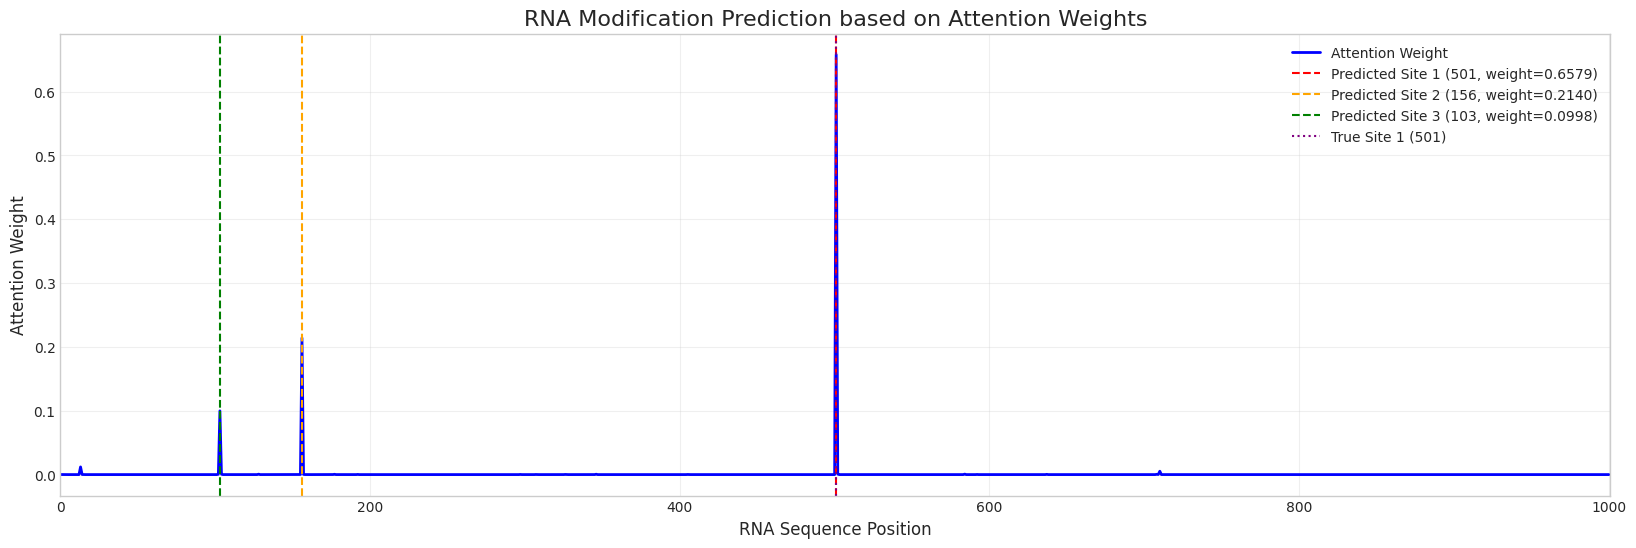

详细可视化图片已保存至: fig/rna_attention_detail.png


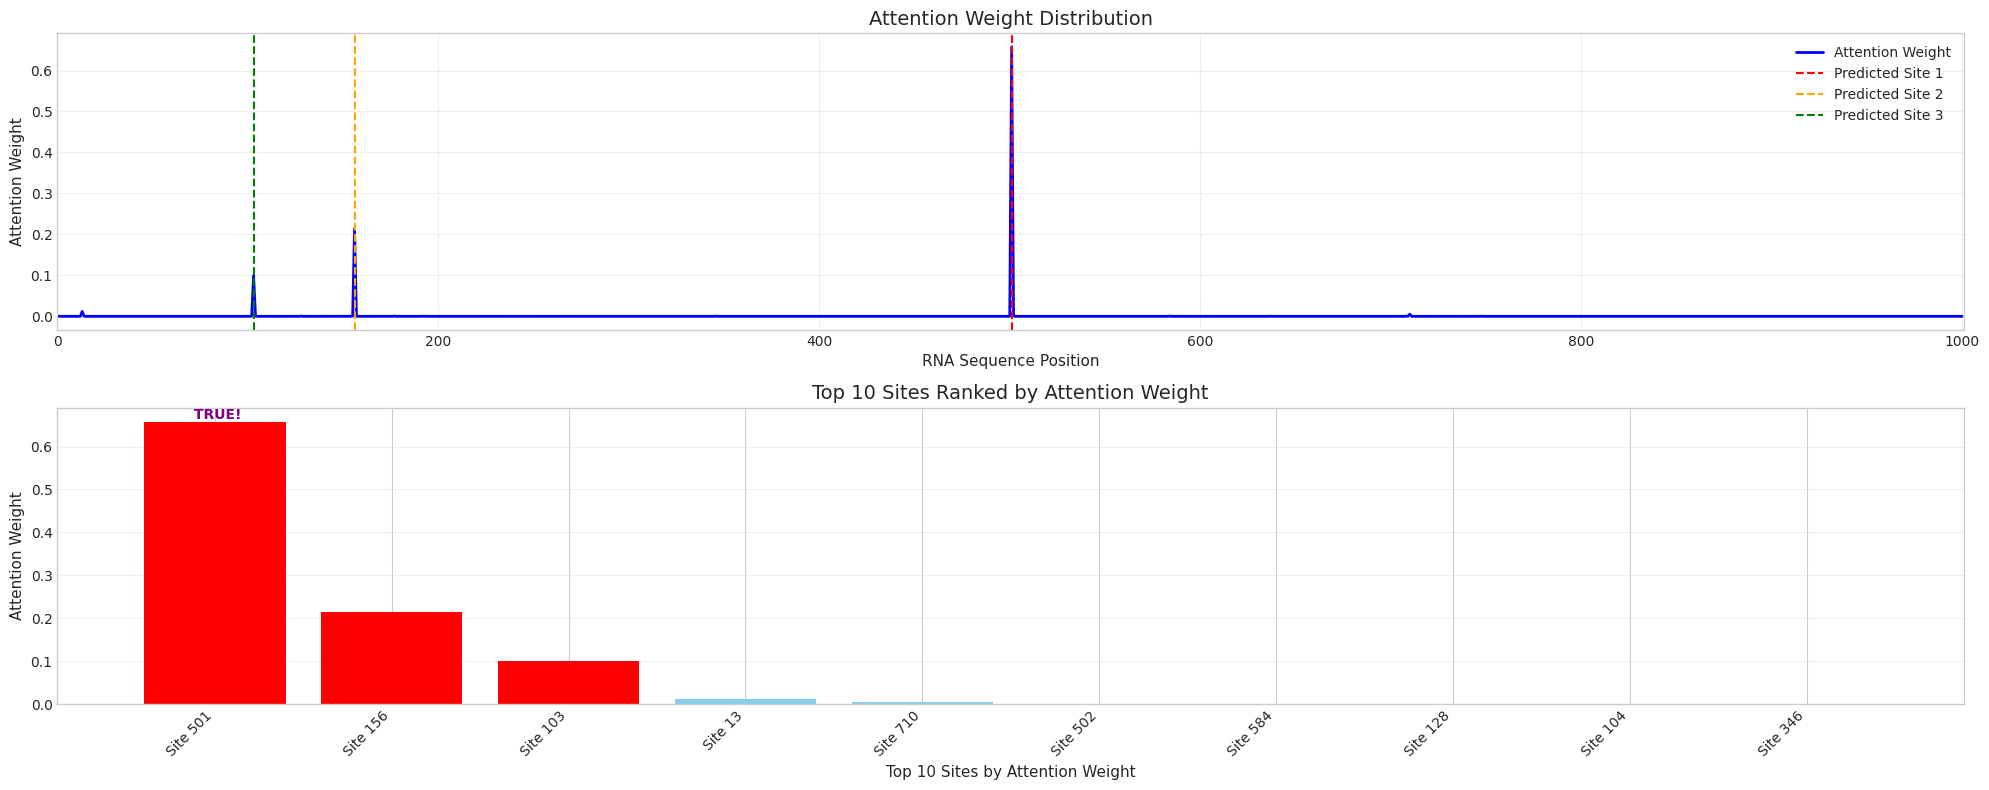

In [13]:
# 使用注意力权重进行可视化
# 提取第一个样本的注意力权重并转换为numpy数组
attention_weights = atten_weight[0].cpu().numpy()  # [12, num_nodes] -> numpy array
print(f"\n注意力权重形状: {attention_weights.shape}")
print(f"注意力权重范围: [{attention_weights.min():.4f}, {attention_weights.max():.4f}]")

# 获取预测为正的修饰类别
predicted_classes = np.where(predictions_12class == 1)[0]
print(f"预测的修饰类别: {predicted_classes}")

# 如果有预测的类别，使用这些类别的注意力权重；否则使用所有类别的平均
if len(predicted_classes) > 0:
    # 计算预测类别的平均注意力权重
    selected_attention = attention_weights[predicted_classes]  # [num_predicted_classes, num_nodes]
    combined_attention = selected_attention.mean(axis=0)  # [num_nodes]
    print(f"使用预测类别 {predicted_classes} 的平均注意力权重")
else:
    # 如果没有预测的类别，使用所有12个类别的平均注意力权重
    combined_attention = attention_weights.mean(axis=0)  # [num_nodes]
    print("使用所有12个类别的平均注意力权重")

print(f"组合后的注意力权重形状: {combined_attention.shape}")
print(f"组合后的注意力权重范围: [{combined_attention.min():.4f}, {combined_attention.max():.4f}]")

# 将注意力权重从高到低排序，取前3个位点作为预测的修饰位点
sorted_indices = np.argsort(combined_attention)[::-1]  # 降序排列
top_3_sites = sorted_indices[:3]
top_3_weights = combined_attention[top_3_sites]

print(f"\n前3个高关注度位点（预测的修饰位点）:")
for i, (site, weight) in enumerate(zip(top_3_sites, top_3_weights)):
    print(f"  Top {i+1}: 位置 {site}, 注意力权重 {weight:.4f}")

# 创建fig文件夹（如果不存在）
import os
fig_dir = 'fig'
os.makedirs(fig_dir, exist_ok=True)

# 可视化注意力权重
plt.figure(figsize=(20, 6))
plt.plot(combined_attention, label='Attention Weight', color='blue', lw=2)

# 标记前3个高关注度位点
colors = ['red', 'orange', 'green']
for i, site in enumerate(top_3_sites):
    plt.axvline(x=site, color=colors[i], linestyle='--', 
                label=f'Predicted Site {i+1} ({site}, weight={combined_attention[site]:.4f})')

# 如果有真实位点，也标记出来
if len(true_sites) > 0:
    for i, true_site in enumerate(true_sites[:3]):  # 最多显示3个真实位点
        plt.axvline(x=true_site, color='purple', linestyle=':', 
                    label=f'True Site {i+1} ({true_site})' if i == 0 else '')

plt.title('RNA Modification Prediction based on Attention Weights', fontsize=16)
plt.xlabel('RNA Sequence Position', fontsize=12)
plt.ylabel('Attention Weight', fontsize=12)
plt.legend()
plt.xlim(0, len(seq))
plt.grid(True, alpha=0.3)

# 保存图片到fig文件夹
fig_path = os.path.join(fig_dir, 'rna_attention_visualization.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n可视化图片已保存至: {fig_path}")
plt.show()

# 创建一个更详细的可视化，展示真实位点和预测位点的对比
plt.figure(figsize=(20, 8))

# 子图1: 注意力权重分布
plt.subplot(2, 1, 1)
plt.plot(combined_attention, label='Attention Weight', color='blue', lw=2)
for i, site in enumerate(top_3_sites):
    plt.axvline(x=site, color=colors[i], linestyle='--', 
                label=f'Predicted Site {i+1}')
plt.title('Attention Weight Distribution', fontsize=14)
plt.xlabel('RNA Sequence Position', fontsize=11)
plt.ylabel('Attention Weight', fontsize=11)
plt.legend()
plt.xlim(0, len(seq))
plt.grid(True, alpha=0.3)

# 子图2: 柱状图显示前10个高关注度位点
plt.subplot(2, 1, 2)
top_10_sites = sorted_indices[:10]
top_10_weights = combined_attention[top_10_sites]
bars = plt.bar(range(len(top_10_sites)), top_10_weights, 
               color=['red' if i < 3 else 'skyblue' for i in range(len(top_10_sites))])
plt.xlabel('Top 10 Sites by Attention Weight', fontsize=11)
plt.ylabel('Attention Weight', fontsize=11)
plt.title('Top 10 Sites Ranked by Attention Weight', fontsize=14)
plt.xticks(range(len(top_10_sites)), [f'Site {site}' for site in top_10_sites], 
           rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# 添加真实位点的标记
if len(true_sites) > 0:
    for i, true_site in enumerate(true_sites):
        if true_site in top_10_sites:
            idx = np.where(top_10_sites == true_site)[0][0]
            plt.text(idx, top_10_weights[idx], ' TRUE!', 
                    ha='center', va='bottom', fontweight='bold', color='purple')

plt.tight_layout()

# 保存详细可视化图片
fig_detail_path = os.path.join(fig_dir, 'rna_attention_detail.png')
plt.savefig(fig_detail_path, dpi=300, bbox_inches='tight')
print(f"详细可视化图片已保存至: {fig_detail_path}")
plt.show()

In [14]:
fig = go.Figure()

# 添加注意力权重曲线
fig.add_trace(go.Scatter(
    x=np.arange(len(seq)),
    y=combined_attention,
    mode='lines',
    name='Attention Weight',
    line=dict(color='blue', width=2),
    hovertext=[f'Base: {seq[i]}<br>Pos: {i}<br>Weight: {w:.4f}' for i, w in enumerate(combined_attention)],
    hoverinfo='text'
))

# 添加前3个预测位点的垂直标记线
colors = ['red', 'orange', 'green']
for i, site in enumerate(top_3_sites):
    fig.add_vline(
        x=site, 
        line_width=2, 
        line_dash="dash", 
        line_color=colors[i], 
        name=f'Predicted Site {i+1} ({site}, weight={combined_attention[site]:.4f})'
    )

# 添加真实位点的垂直标记线
if len(true_sites) > 0:
    for i, true_site in enumerate(true_sites[:3]):
        fig.add_vline(
            x=true_site, 
            line_width=2, 
            line_dash="dot", 
            line_color="purple", 
            name=f'True Site {i+1} ({true_site})' if i == 0 else None
        )

fig.update_layout(
    title='RNA Modification Prediction based on Attention Weights (Plotly)',
    xaxis_title='RNA Sequence Position',
    yaxis_title='Attention Weight',
    legend_title='Markers',
    hovermode='closest'
)

fig.show()


GCN图结构可视化
图节点数: 1001
图边数: 1000
图平均度数: 2.00
GCN图结构可视化已保存至: fig/gcn_graph_visualization.png


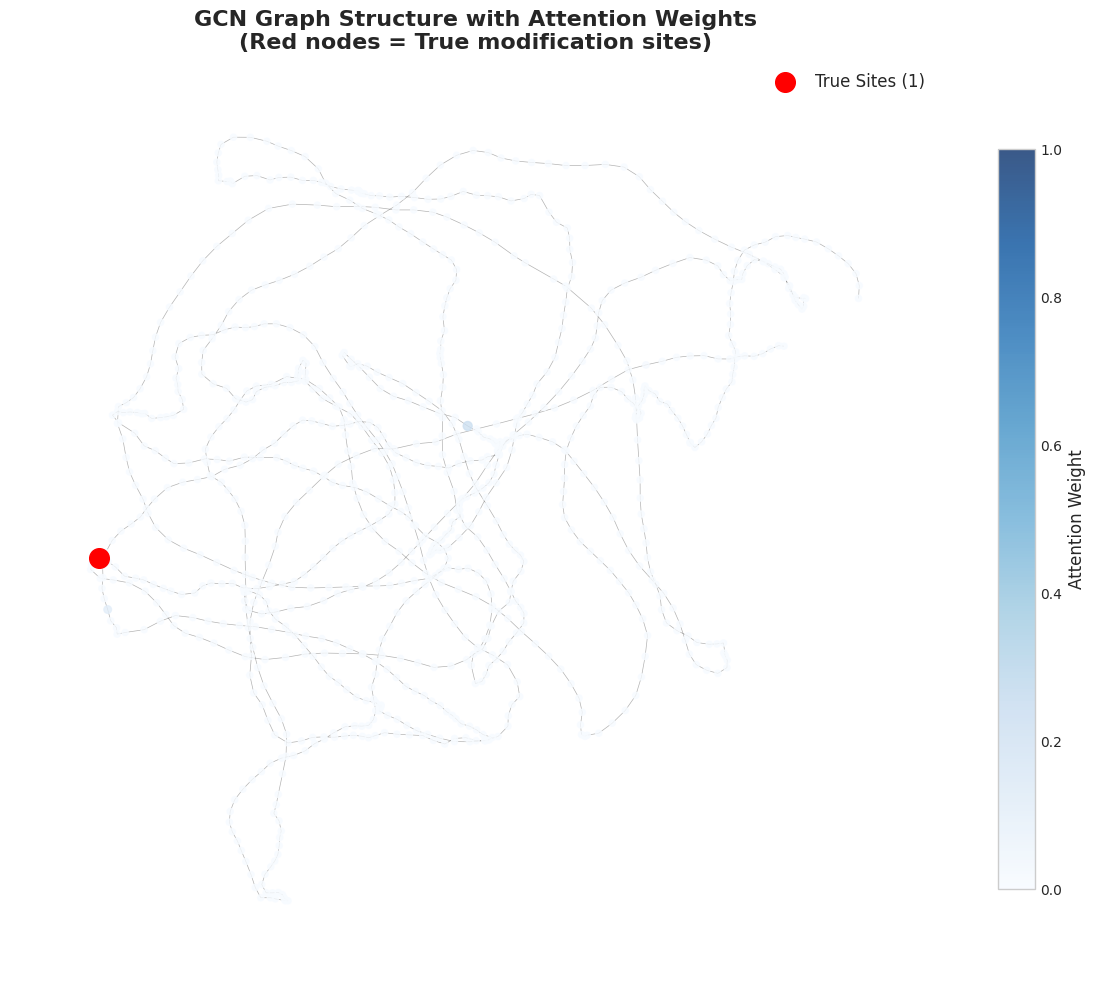

邻接矩阵热力图已保存至: fig/adjacency_matrix_heatmap.png


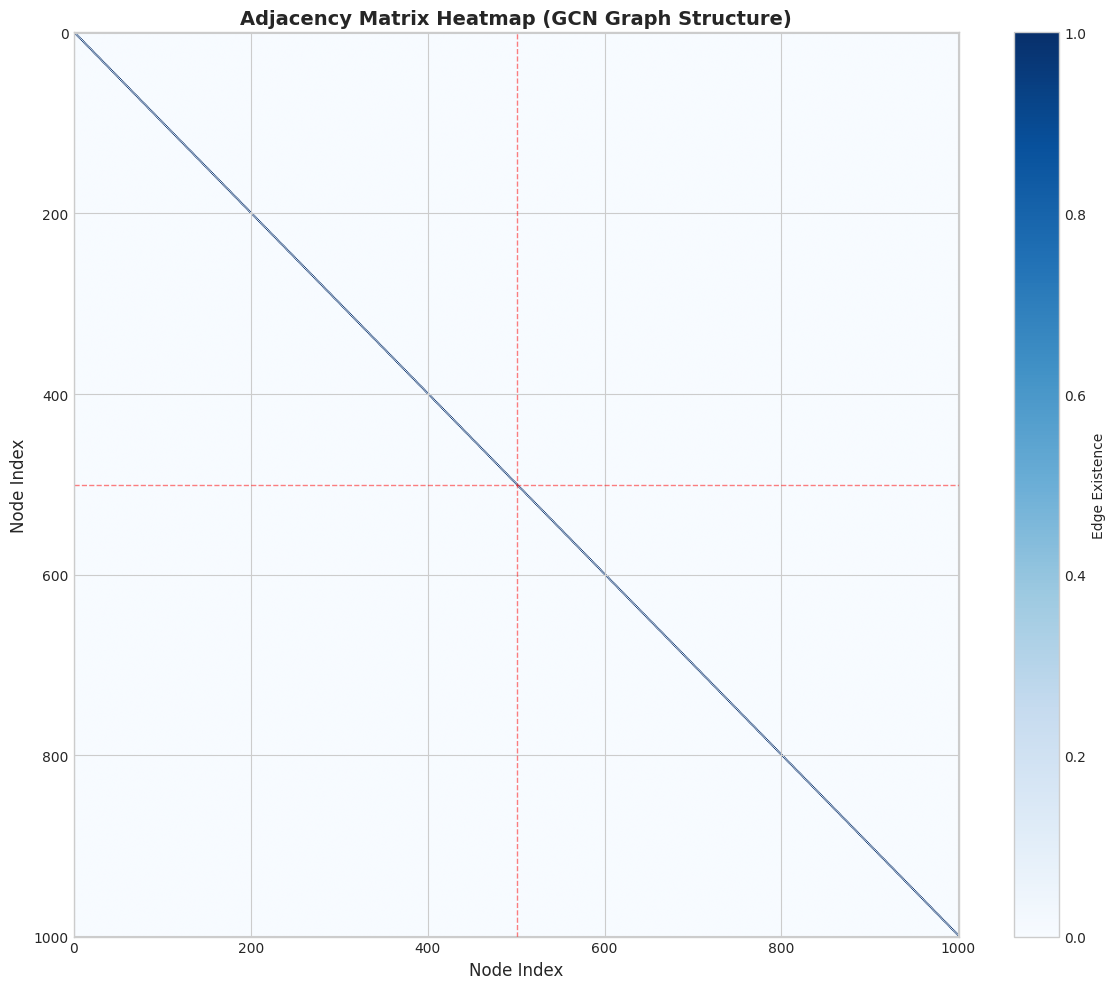

In [15]:
# 可视化GCN图结构（使用邻接矩阵）
print(f"\n{'='*80}")
print(f"GCN图结构可视化")
print(f"{'='*80}")

# 创建图对象
G = nx.from_numpy_array(adj_matrix)

print(f"图节点数: {G.number_of_nodes()}")
print(f"图边数: {G.number_of_edges()}")
print(f"图平均度数: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# 设置节点颜色：根据注意力权重进行着色
node_colors = combined_attention

# 如果有真实位点，用特殊颜色标记
if len(true_sites) > 0:
    for site in true_sites:
        if site < G.number_of_nodes():
            node_colors[site] = -1  # 用-1标记真实位点，后面会特殊处理

# 创建节点大小：注意力权重越大，节点越大
node_sizes = 20 + combined_attention * 100

plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G)

# 绘制边
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)

# 绘制节点（除了真实位点）
nodes = None
normal_nodes = [i for i in range(G.number_of_nodes()) if len(true_sites) == 0 or i not in true_sites]
if normal_nodes:
    nodes = nx.draw_networkx_nodes(G, pos, nodelist=normal_nodes, 
                          node_color=node_colors[normal_nodes],
                          node_size=node_sizes[normal_nodes],
                          cmap='Blues', vmin=0, vmax=1,
                          alpha=0.8)

# 绘制真实位点（用红色高亮）
if len(true_sites) > 0:
    true_nodes_in_graph = [site for site in true_sites if site < G.number_of_nodes()]
    if true_nodes_in_graph:
        nx.draw_networkx_nodes(G, pos, nodelist=true_nodes_in_graph,
                              node_color='red',
                              node_size=200,
                              alpha=1.0,
                              label=f'True Sites ({len(true_nodes_in_graph)})')

# 添加颜色条
if nodes:
    cbar = plt.colorbar(nodes, shrink=0.8)
    cbar.set_label('Attention Weight', fontsize=12)

# 添加图例和标题
plt.legend(loc='upper right', fontsize=12)
plt.title('GCN Graph Structure with Attention Weights\n(Red nodes = True modification sites)', 
          fontsize=16, fontweight='bold')
plt.axis('off')

# 保存图可视化
fig_graph_path = os.path.join(fig_dir, 'gcn_graph_visualization.png')
plt.savefig(fig_graph_path, dpi=300, bbox_inches='tight')
print(f"GCN图结构可视化已保存至: {fig_graph_path}")
plt.show()

# 额外：显示邻接矩阵的热力图
plt.figure(figsize=(12, 10))
plt.imshow(adj_matrix, cmap='Blues', aspect='auto')
plt.colorbar(label='Edge Existence')
plt.title('Adjacency Matrix Heatmap (GCN Graph Structure)', fontsize=14, fontweight='bold')
plt.xlabel('Node Index', fontsize=12)
plt.ylabel('Node Index', fontsize=12)

# 标记真实位点
if len(true_sites) > 0:
    for site in true_sites:
        plt.axvline(x=site, color='red', linestyle='--', alpha=0.5, linewidth=1)
        plt.axhline(y=site, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
fig_adj_path = os.path.join(fig_dir, 'adjacency_matrix_heatmap.png')
plt.savefig(fig_adj_path, dpi=300, bbox_inches='tight')
print(f"邻接矩阵热力图已保存至: {fig_adj_path}")
plt.show()

In [16]:

# 1. 从邻接矩阵提取碱基对
pairs = []
for i in range(adj_matrix.shape[0]):
    for j in range(i + 1, adj_matrix.shape[1]):
        if adj_matrix[i, j] == 1 and abs(i - j) > 3: # 假设距离大于3的连接为配对
            pairs.append((i, j))

print(f"找到 {len(pairs)} 个碱基对")

# 2. 如果 forgi 可用，则进行二级结构可视化
if FORGI_AVAILABLE:
    # 如果没有找到碱基对，跳过可视化
    if not pairs:
        print("注意：未找到碱基对，跳过 forgi 二级结构可视化。")
    else:
        try:
            # 构建点括号表示的二级结构
            structure = ['.'] * len(seq)
            for i, j in pairs:
                structure[i] = '('
                structure[j] = ')'
            structure_str = ''.join(structure)
            
            # 从序列和结构字符串创建 BulgeGraph
            # 注意：forgi API 可能有变动，确保使用正确的模块路径
            import forgi.graph.bulge_graph as fgb
            bg = fgb.BulgeGraph.from_dotbracket(structure_str)
            
            # 3. 定义要高亮的位点和颜色
            # 使用 true_sites (复数) 的第一个位点
            true_site_to_highlight = -1
            if len(true_sites) > 0:
                true_site_to_highlight = true_sites[0]

            colors = {true_site_to_highlight + 1: 'red'} if true_site_to_highlight >= 0 else None
            
            # 4. 绘图
            fig, ax = plt.subplots(figsize=(10, 10))
            fvm.plot_rna(bg, ax=ax, colors=colors)  # 添加 colors 参数
            title = 'RNA Secondary Structure (forgi)'
            if true_site_to_highlight >= 0:
                title += f' - Site {true_site_to_highlight} highlighted'
            ax.set_title(title)
            plt.show()
        except Exception as e:
            print(f"注意：forgi 可视化失败: {e}")
            print("这可能是因为邻接矩阵不代表有效的二级结构，或者 forgi 版本/方法不兼容")
            print("建议：使用 LinearFold 生成二级结构，然后从结构字符串构建 BulgeGraph")
else:
    print("注意：forgi 未安装，跳过二级结构可视化")
    print("安装命令: pip install forgi")


找到 0 个碱基对
注意：未找到碱基对，跳过 forgi 二级结构可视化。
